In [58]:
# Загрузка датасета через kagglehub и чтение CSV-файла с орбитальными данными
import kagglehub
import pandas as pd

path = kagglehub.dataset_download(
    "kandhalkhandeka/satellites-and-debris-in-earths-orbit"
)

print("Dataset path:", path)

df = pd.read_csv(path + "/space_decay.csv")

df.head()

Using Colab cache for faster access to the 'satellites-and-debris-in-earths-orbit' dataset.
Dataset path: /kaggle/input/satellites-and-debris-in-earths-orbit


,CCSDS_OMM_VERS,COMMENT,CREATION_DATE,ORIGINATOR,OBJECT_NAME,OBJECT_ID,CENTER_NAME,REF_FRAME,TIME_SYSTEM,MEAN_ELEMENT_THEORY,EPOCH,MEAN_MOTION,ECCENTRICITY,INCLINATION,RA_OF_ASC_NODE,ARG_OF_PERICENTER,MEAN_ANOMALY,EPHEMERIS_TYPE,CLASSIFICATION_TYPE,NORAD_CAT_ID,ELEMENT_SET_NO,REV_AT_EPOCH,BSTAR,MEAN_MOTION_DOT,MEAN_MOTION_DDOT,SEMIMAJOR_AXIS,PERIOD,APOAPSIS,PERIAPSIS,OBJECT_TYPE,RCS_SIZE,COUNTRY_CODE,LAUNCH_DATE,SITE,DECAY_DATE,FILE,GP_ID,TLE_LINE0,TLE_LINE1,TLE_LINE2
0,2,GENERATED VIA SPACE-TRACK.ORG API,2021-11-01T06:46:11,18 SPCS,ARIANE 42P+ DEB,1992-072J,EARTH,TEME,UTC,SGP4,2021-10-31T22:46:50.340864,2.921700,0.652893,7.7156,90.2410,243.1216,38.7796,0,U,26741,999,23588,0.024341,8.830000e-06,0.0,20668.618,492.864,27784.871,796.095,DEBRIS,MEDIUM,FR,1992.0,FRGUI,NaN,3195178,188614016,0 ARIANE 42P+ DEB,1 26741U 92072J 21304.94919376 .00000883 0...,2 26741 7.7156 90.2410 6528926 243.1216 38...
1,2,GENERATED VIA SPACE-TRACK.ORG API,2021-11-01T04:58:37,18 SPCS,SL-8 DEB,1979-028C,EARTH,TEME,UTC,SGP4,2021-10-31T16:32:17.360448,13.754973,0.003072,82.9193,299.1120,158.9093,201.3337,0,U,26743,999,50124,0.000066,7.900000e-07,0.0,7358.038,104.689,1002.507,957.299,DEBRIS,SMALL,CIS,1979.0,PKMTR,NaN,3194950,188593285,0 SL-8 DEB,1 26743U 79028C 21304.68908982 .00000079 0...,2 26743 82.9193 299.1120 0030720 158.9093 201...
2,2,GENERATED VIA SPACE-TRACK.ORG API,2021-11-01T06:26:11,18 SPCS,GSAT 1,2001-015A,EARTH,TEME,UTC,SGP4,2021-11-01T05:22:43.421952,1.038224,0.023739,12.1717,16.5368,250.1248,146.2900,0,U,26745,999,7798,0.000000,-1.650000e-06,0.0,41197.852,1386.984,35797.696,33841.738,PAYLOAD,LARGE,IND,2001.0,SRI,NaN,3195026,188609573,0 GSAT 1,1 26745U 01015A 21305.22411368 -.00000165 0...,2 26745 12.1717 16.5368 0237386 250.1248 146...
3,2,GENERATED VIA SPACE-TRACK.ORG API,2021-10-31T18:07:15,18 SPCS,CZ-4 DEB,1999-057MB,EARTH,TEME,UTC,SGP4,2021-10-31T11:11:24.198720,14.775907,0.006062,98.4781,8.7205,37.3771,323.1632,0,U,26754,999,10204,0.000316,2.265000e-05,0.0,7015.076,97.456,679.465,594.417,DEBRIS,SMALL,PRC,1999.0,TSC,NaN,3194431,188556894,0 CZ-4 DEB,1 26754U 99057MB 21304.46625230 .00002265 0...,2 26754 98.4781 8.7205 0060618 37.3771 323...
4,2,GENERATED VIA SPACE-TRACK.ORG API,2021-11-01T04:58:37,18 SPCS,CZ-4 DEB,1999-057MC,EARTH,TEME,UTC,SGP4,2021-10-31T17:46:46.681248,14.724482,0.006226,98.4232,122.0724,345.1605,27.6061,0,U,26755,999,9622,0.000408,2.610000e-05,0.0,7031.400,97.796,697.039,609.491,DEBRIS,SMALL,PRC,1999.0,TSC,NaN,3194950,188592541,0 CZ-4 DEB,1 26755U 99057MC 21304.74081807 .00002610 0...,2 26755 98.4232 122.0724 0062255 345.1605 27...


In [59]:
# Импорт библиотек для работы с данными и визуализации
# Удаление технических и служебных столбцов, не несущих аналитической ценности:
# TLE-строки (TLE_LINE0/1/2), метаданные (CREATION_DATE, FILE, GP_ID),
# константные поля (COMMENT, ORIGINATOR, CENTER_NAME, REF_FRAME и т.д.)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
df.drop(columns=[
 'CCSDS_OMM_VERS', 'COMMENT', 'ORIGINATOR', 'CENTER_NAME',
 'REF_FRAME', 'TIME_SYSTEM', 'MEAN_ELEMENT_THEORY',
 'EPHEMERIS_TYPE', 'CLASSIFICATION_TYPE', 'ELEMENT_SET_NO',
 'MEAN_MOTION_DDOT', 'DECAY_DATE', 'FILE', 'GP_ID',
 'TLE_LINE0', 'TLE_LINE1', 'TLE_LINE2', 'OBJECT_ID',
 'CREATION_DATE', 'REV_AT_EPOCH', 'MEAN_MOTION_DOT', 'OBJECT_NAME'
]
, inplace=True)

df.head()

,EPOCH,MEAN_MOTION,ECCENTRICITY,INCLINATION,RA_OF_ASC_NODE,ARG_OF_PERICENTER,MEAN_ANOMALY,NORAD_CAT_ID,BSTAR,SEMIMAJOR_AXIS,PERIOD,APOAPSIS,PERIAPSIS,OBJECT_TYPE,RCS_SIZE,COUNTRY_CODE,LAUNCH_DATE,SITE
0,2021-10-31T22:46:50.340864,2.921700,0.652893,7.7156,90.2410,243.1216,38.7796,26741,0.024341,20668.618,492.864,27784.871,796.095,DEBRIS,MEDIUM,FR,1992.0,FRGUI
1,2021-10-31T16:32:17.360448,13.754973,0.003072,82.9193,299.1120,158.9093,201.3337,26743,0.000066,7358.038,104.689,1002.507,957.299,DEBRIS,SMALL,CIS,1979.0,PKMTR
2,2021-11-01T05:22:43.421952,1.038224,0.023739,12.1717,16.5368,250.1248,146.2900,26745,0.000000,41197.852,1386.984,35797.696,33841.738,PAYLOAD,LARGE,IND,2001.0,SRI
3,2021-10-31T11:11:24.198720,14.775907,0.006062,98.4781,8.7205,37.3771,323.1632,26754,0.000316,7015.076,97.456,679.465,594.417,DEBRIS,SMALL,PRC,1999.0,TSC
4,2021-10-31T17:46:46.681248,14.724482,0.006226,98.4232,122.0724,345.1605,27.6061,26755,0.000408,7031.400,97.796,697.039,609.491,DEBRIS,SMALL,PRC,1999.0,TSC


In [60]:
# Преобразование столбца EPOCH из строки в формат datetime для корректной работы с датами
df['EPOCH'] = pd.to_datetime(df['EPOCH']) #Convert EPOCH to datetime
df.head()

,EPOCH,MEAN_MOTION,ECCENTRICITY,INCLINATION,RA_OF_ASC_NODE,ARG_OF_PERICENTER,MEAN_ANOMALY,NORAD_CAT_ID,BSTAR,SEMIMAJOR_AXIS,PERIOD,APOAPSIS,PERIAPSIS,OBJECT_TYPE,RCS_SIZE,COUNTRY_CODE,LAUNCH_DATE,SITE
0,2021-10-31 22:46:50.340864,2.921700,0.652893,7.7156,90.2410,243.1216,38.7796,26741,0.024341,20668.618,492.864,27784.871,796.095,DEBRIS,MEDIUM,FR,1992.0,FRGUI
1,2021-10-31 16:32:17.360448,13.754973,0.003072,82.9193,299.1120,158.9093,201.3337,26743,0.000066,7358.038,104.689,1002.507,957.299,DEBRIS,SMALL,CIS,1979.0,PKMTR
2,2021-11-01 05:22:43.421952,1.038224,0.023739,12.1717,16.5368,250.1248,146.2900,26745,0.000000,41197.852,1386.984,35797.696,33841.738,PAYLOAD,LARGE,IND,2001.0,SRI
3,2021-10-31 11:11:24.198720,14.775907,0.006062,98.4781,8.7205,37.3771,323.1632,26754,0.000316,7015.076,97.456,679.465,594.417,DEBRIS,SMALL,PRC,1999.0,TSC
4,2021-10-31 17:46:46.681248,14.724482,0.006226,98.4232,122.0724,345.1605,27.6061,26755,0.000408,7031.400,97.796,697.039,609.491,DEBRIS,SMALL,PRC,1999.0,TSC


In [61]:
# Разделение признаков на числовые и категориальные для раздельной обработки
num_cols = [c for c in df.columns if pd.api.types.is_numeric_dtype(df[c])]
cat_cols = [c for c in df.columns if df[c].dtype == 'O']
print("Numerical characteristics:", num_cols)
print("Categorical characteristics:", cat_cols)

Numerical characteristics: ['MEAN_MOTION', 'ECCENTRICITY', 'INCLINATION', 'RA_OF_ASC_NODE', 'ARG_OF_PERICENTER', 'MEAN_ANOMALY', 'NORAD_CAT_ID', 'BSTAR', 'SEMIMAJOR_AXIS', 'PERIOD', 'APOAPSIS', 'PERIAPSIS', 'LAUNCH_DATE']
Categorical characteristics: ['OBJECT_TYPE', 'RCS_SIZE', 'COUNTRY_CODE', 'SITE']


In [62]:
# Проверка пропущенных значений по каждому столбцу
df.isna().sum()


,0
EPOCH,0
MEAN_MOTION,0
ECCENTRICITY,0
INCLINATION,0
RA_OF_ASC_NODE,0
ARG_OF_PERICENTER,0
MEAN_ANOMALY,0
NORAD_CAT_ID,0
BSTAR,0
SEMIMAJOR_AXIS,0


In [63]:
# Заполнение пропусков: для категориальных — мода (наиболее частое значение),
# для числовых — среднее арифметическое
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])
df[num_cols]=df[num_cols].fillna(df[num_cols].mean())


In [64]:
# Повторная проверка пропусков после заполнения — убеждаемся, что пропусков не осталось
df.isna().sum()


,0
EPOCH,0
MEAN_MOTION,0
ECCENTRICITY,0
INCLINATION,0
RA_OF_ASC_NODE,0
ARG_OF_PERICENTER,0
MEAN_ANOMALY,0
NORAD_CAT_ID,0
BSTAR,0
SEMIMAJOR_AXIS,0


In [65]:
# Поиск полностью одинаковых строк в датасете
dub_all = df.duplicated()
print('Complete duplicates: ', dub_all.sum())

Complete duplicates:  0


In [66]:
# Поиск дубликатов по ключевым полям: один объект (NORAD_CAT_ID) не может иметь
# две одинаковые записи для одного момента времени (EPOCH)
dups = df[df.duplicated(subset=['NORAD_CAT_ID', 'EPOCH'], keep=False)]
print('Duplicates by key:', len(dups))

Duplicates by key: 0


In [67]:
# Проверка физических аномалий в данных:
# - наклонение орбиты должно быть в диапазоне [0, 180] градусов
# - высоты апогея и перигея не могут быть отрицательными
# - перигей (нижняя точка) не может быть выше апогея (верхней точки)
anomalies = df[
    (df['INCLINATION'] < 0) |
    (df['INCLINATION'] > 180) |
    (df['APOAPSIS'] < 0) |
    (df['PERIAPSIS'] < 0) |
    (df['PERIAPSIS'] > df['APOAPSIS'])
]
print("Anomalous entries:", len(anomalies))


Anomalous entries: 0


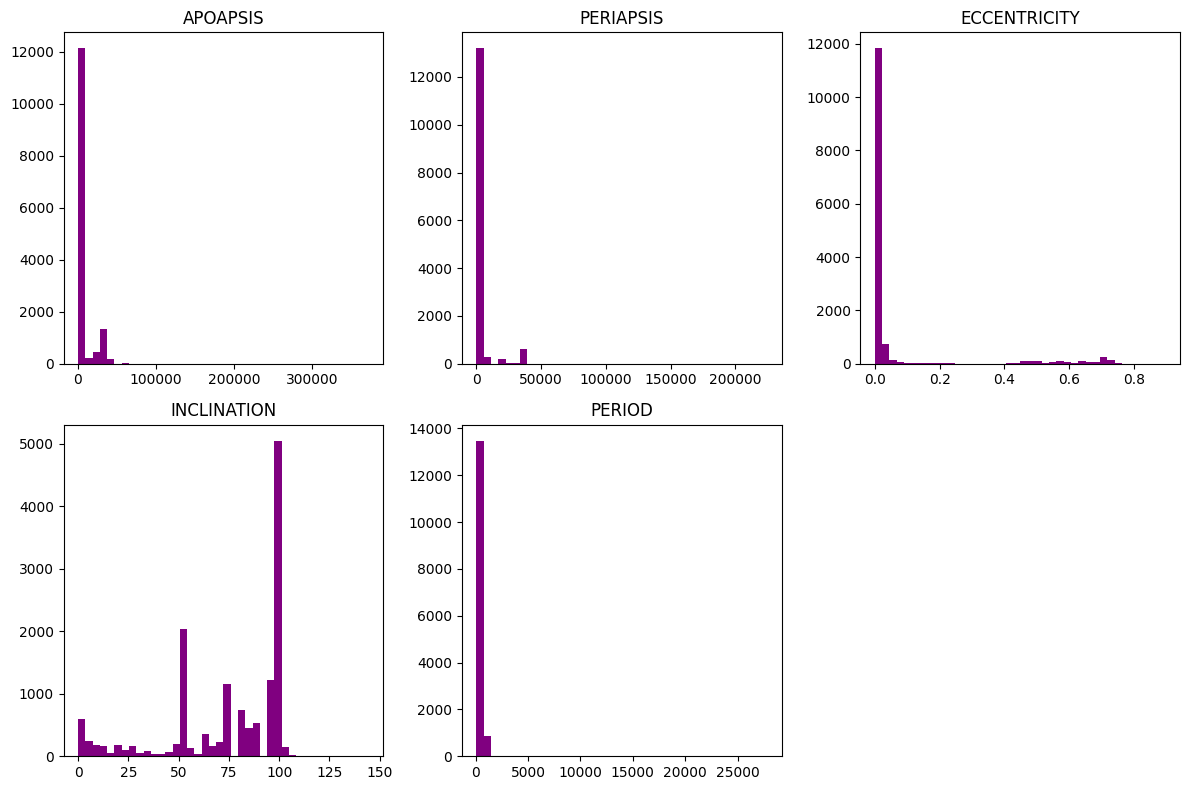

In [68]:
# Построение гистограмм распределения для ключевых орбитальных параметров
important_nums = ['APOAPSIS', 'PERIAPSIS', 'ECCENTRICITY', 'INCLINATION', 'PERIOD']
plt.figure(figsize=(12, 8))

for i, col in enumerate(important_nums, 1):
    if col in df.columns:
        plt.subplot(2, 3, i)
        plt.hist(df[col], bins=40, color='purple')
        plt.title(col)

plt.tight_layout()
plt.show()

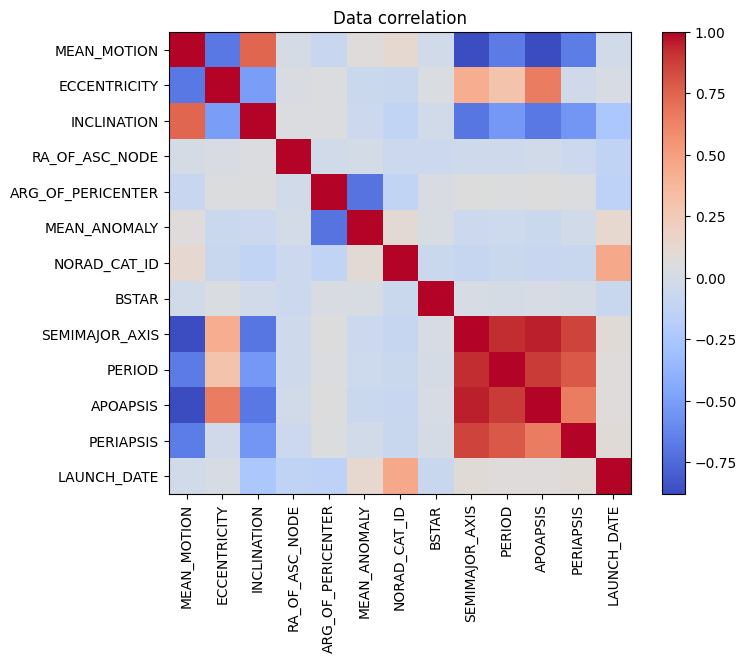

In [69]:
# Тепловая карта корреляций между числовыми признаками.
# Помогает обнаружить сильно коррелирующие (избыточные) признаки
corr = df[num_cols].corr(numeric_only=True)
plt.figure(figsize=(8, 6))
plt.imshow(corr, cmap='coolwarm', interpolation='nearest')
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.colorbar()
plt.title("Data correlation")
plt.show()


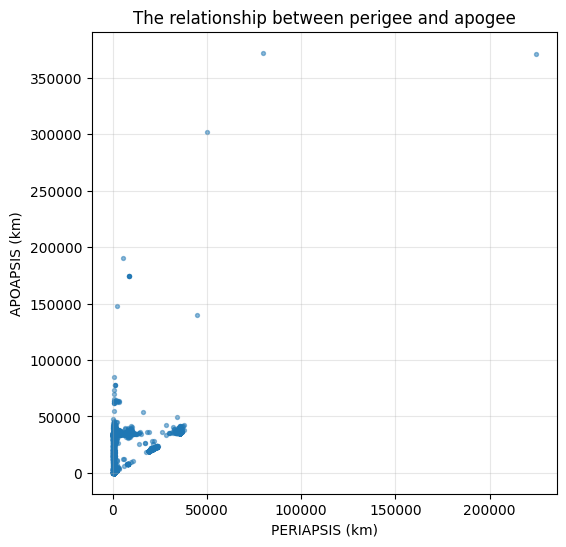

In [70]:
# Диаграмма рассеяния: зависимость высоты апогея от высоты перигея.
# Ожидаем линейную связь для объектов с круговыми орбитами
plt.figure(figsize=(6,6))
plt.scatter(df['PERIAPSIS'], df['APOAPSIS'], s=8, alpha=0.5)
plt.xlabel("PERIAPSIS (km)")
plt.ylabel("APOAPSIS (km)")
plt.title("The relationship between perigee and apogee")
plt.grid(True, alpha=0.3)
plt.show()


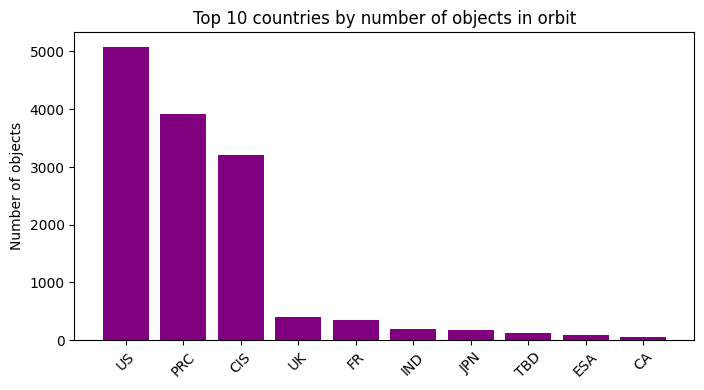

In [71]:
# Топ-10 стран по количеству объектов на орбите (спутники + мусор)
country_counts = df['COUNTRY_CODE'].value_counts().head(10)
plt.figure(figsize=(8,4))
plt.bar(country_counts.index, country_counts.values, color='purple')
plt.title("Top 10 countries by number of objects in orbit")
plt.ylabel("Number of objects")
plt.xticks(rotation=45)
plt.show()


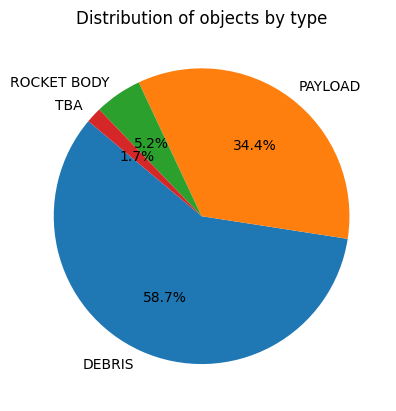

In [72]:
# Круговая диаграмма распределения объектов по типу: PAYLOAD, DEBRIS, ROCKET BODY и др.
type_counts = df['OBJECT_TYPE'].value_counts()
plt.pie(type_counts, labels=type_counts.index, autopct='%1.1f%%', startangle=140)
plt.title("Distribution of objects by type")
plt.show()


In [73]:
# Создание нового признака ALT_MEAN — средняя высота орбиты
# как среднее между апогеем и перигеем
df['ALT_MEAN'] = (df['APOAPSIS'] + df['PERIAPSIS']) / 2


Text(0.5, 1.0, 'ALT_MEAN')

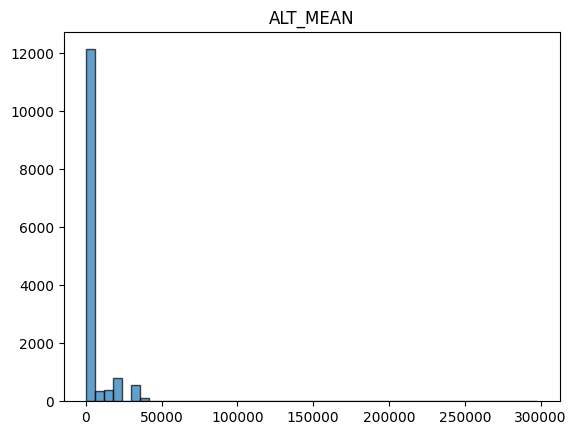

In [74]:
# Гистограмма распределения средней высоты орбиты ALT_MEAN
feature = 'ALT_MEAN'
data = df[feature].dropna()
plt.subplot(1, 1, 1)
plt.hist(data, bins=50, edgecolor='black', alpha=0.7)
plt.title(feature)



In [77]:
# Классификация орбит по средней высоте:
# LEO (низкая)  — до 2000 км
# MEO (средняя) — от 2000 до 35786 км
# GEO (геостационарная) — выше 35786 км
def orbit_class(h):
    if pd.isna(h):
      return np.nan
    if h < 2000:
      return 'LEO'
    elif h < 35786:
      return 'MEO'
    else:
      return 'GEO'

df['ORBIT_CLASS'] = df['ALT_MEAN'].apply(orbit_class)
df['ORBIT_CLASS'].value_counts()


,count
ORBIT_CLASS,
LEO,11983
MEO,1836
GEO,553


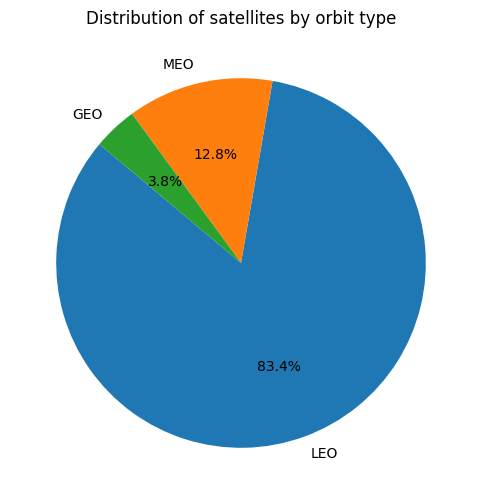

In [ ]:
# Визуализация распределения спутников по классам орбит
import matplotlib.pyplot as plt

orbit_counts = df['ORBIT_CLASS'].value_counts()
plt.figure(figsize=(6, 6))
plt.pie(orbit_counts, labels=orbit_counts.index, autopct='%1.1f%%', startangle=140)
plt.title("Distribution of satellites by orbit type")
plt.show()


In [ ]:
# Проверка корректности созданных признаков ALT_MEAN и ORBIT_CLASS
df[['ALT_MEAN', 'ORBIT_CLASS']].head()


,ALT_MEAN,ORBIT_CLASS
0,14290.483,MEO
1,979.903,LEO
2,34819.717,MEO
3,636.941,LEO
4,653.265,LEO


In [ ]:
# Средняя высота орбиты в разбивке по типу объекта.
# Ожидаем, что спутники (PAYLOAD) в среднем выше мусора (DEBRIS)
df.groupby('OBJECT_TYPE')['ALT_MEAN'].mean().sort_values(ascending=False)


,ALT_MEAN
OBJECT_TYPE,
ROCKET BODY,13411.171096
PAYLOAD,5564.941582
DEBRIS,2785.959923
TBA,744.523925


In [ ]:
# Определение выбросов: объекты с ALT_MEAN за пределами допустимого диапазона [0, 50000] км
lower_bound = 0
upper_bound = 50000
outliers = df[(df["ALT_MEAN"] < lower_bound) | (df["ALT_MEAN"] > upper_bound)]
print("Amount of emissions:", len(outliers))


Amount of emissions: 10


In [ ]:
# Стратегия 1: удаление выбросов — исключаем строки с ALT_MEAN > 50000 км
df_no_outliers = df[(df["ALT_MEAN"] <= 50000)]

In [ ]:
# Стратегия 2: ограничение (capping) — заменяем выбросы пороговыми значениями
# вместо удаления строк
df_capped = df.copy()
df_capped.loc[df_capped["ALT_MEAN"] < lower_bound, "ALT_MEAN"] = lower_bound
df_capped.loc[df_capped["ALT_MEAN"] > upper_bound, "ALT_MEAN"] = upper_bound

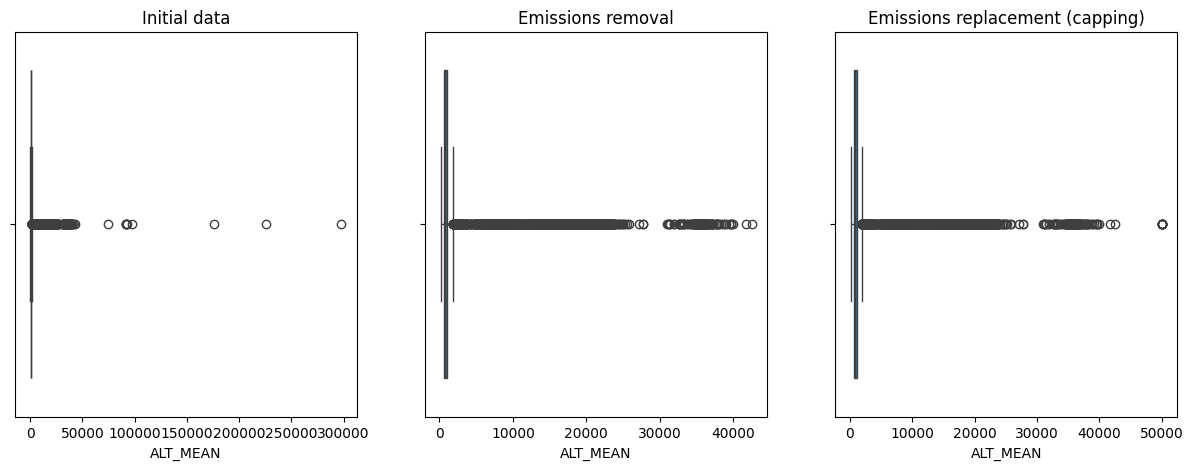

In [ ]:
# Сравнение трёх вариантов на ящичных диаграммах:
# исходные данные / после удаления выбросов / после ограничения (capping)
import seaborn as sns
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.boxplot(x=df["ALT_MEAN"], ax=axes[0])
axes[0].set_title("Initial data")

sns.boxplot(x=df_no_outliers["ALT_MEAN"], ax=axes[1])
axes[1].set_title("Emissions removal")

sns.boxplot(x=df_capped["ALT_MEAN"], ax=axes[2])
axes[2].set_title("Emissions replacement (capping)")

plt.show()

In [ ]:
# Выбираем стратегию удаления выбросов как основную
df = df_no_outliers


In [ ]:
# One-Hot Encoding признака RCS_SIZE (размер объекта: SMALL/MEDIUM/LARGE)
# Создаём бинарные столбцы для каждой категории
rcs_dummies = pd.get_dummies(df['RCS_SIZE'], prefix='RCS_SIZE')

df = pd.concat([df, rcs_dummies], axis=1)

df.head()[['RCS_SIZE'] + list(rcs_dummies.columns)]


,RCS_SIZE,RCS_SIZE_LARGE,RCS_SIZE_MEDIUM,RCS_SIZE_SMALL
0,MEDIUM,False,True,False
1,SMALL,False,False,True
2,LARGE,True,False,False
3,SMALL,False,False,True
4,SMALL,False,False,True


In [ ]:
# One-Hot Encoding признака OBJECT_TYPE (тип объекта)
rcs_dummies = pd.get_dummies(df['OBJECT_TYPE'], prefix='OBJECT_TYPE')

df = pd.concat([df, rcs_dummies], axis=1)

df.head()[['OBJECT_TYPE'] + list(rcs_dummies.columns)]

,OBJECT_TYPE,OBJECT_TYPE_DEBRIS,OBJECT_TYPE_PAYLOAD,OBJECT_TYPE_ROCKET BODY,OBJECT_TYPE_TBA
0,DEBRIS,True,False,False,False
1,DEBRIS,True,False,False,False
2,PAYLOAD,False,True,False,False
3,DEBRIS,True,False,False,False
4,DEBRIS,True,False,False,False


In [ ]:
# One-Hot Encoding признака SITE (космодром запуска)
rcs_dummies = pd.get_dummies(df['SITE'], prefix='SITE')

df = pd.concat([df, rcs_dummies], axis=1)

df.head()[['SITE'] + list(rcs_dummies.columns)]

,SITE,SITE_AFETR,SITE_AFWTR,SITE_ERAS,SITE_FRGUI,SITE_JSC,SITE_KODAK,SITE_KSCUT,SITE_KWAJL,SITE_KYMTR,SITE_NSC,SITE_OREN,SITE_PKMTR,SITE_RLLC,SITE_SEAL,SITE_SMTS,SITE_SRI,SITE_SVOB,SITE_TNSTA,SITE_TSC,SITE_TTMTR,SITE_VOSTO,SITE_WLPIS,SITE_WRAS,SITE_WSC,SITE_XSC,SITE_YSLA,SITE_YUN
0,FRGUI,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,PKMTR,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,SRI,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False
3,TSC,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False
4,TSC,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False


In [ ]:
# Удаление исходных категориальных столбцов после их кодирования,
# а также вспомогательных признаков (COUNTRY_CODE, ORBIT_CLASS, ALT_MEAN)
df = df.drop(columns=['COUNTRY_CODE', 'COUNTRY', 'ORBIT_CLASS', 'RCS_SIZE', 'OBJECT_TYPE', 'SITE', 'ALT_MEAN'], errors='ignore')



In [ ]:
# Проверка итоговой структуры датафрейма после всех преобразований
df.head()

,EPOCH,MEAN_MOTION,ECCENTRICITY,INCLINATION,RA_OF_ASC_NODE,ARG_OF_PERICENTER,MEAN_ANOMALY,NORAD_CAT_ID,BSTAR,SEMIMAJOR_AXIS,PERIOD,APOAPSIS,PERIAPSIS,LAUNCH_DATE,RCS_SIZE_LARGE,RCS_SIZE_MEDIUM,RCS_SIZE_SMALL,OBJECT_TYPE_DEBRIS,OBJECT_TYPE_PAYLOAD,OBJECT_TYPE_ROCKET BODY,OBJECT_TYPE_TBA,SITE_AFETR,SITE_AFWTR,SITE_ERAS,SITE_FRGUI,SITE_JSC,SITE_KODAK,SITE_KSCUT,SITE_KWAJL,SITE_KYMTR,SITE_NSC,SITE_OREN,SITE_PKMTR,SITE_RLLC,SITE_SEAL,SITE_SMTS,SITE_SRI,SITE_SVOB,SITE_TNSTA,SITE_TSC,SITE_TTMTR,SITE_VOSTO,SITE_WLPIS,SITE_WRAS,SITE_WSC,SITE_XSC,SITE_YSLA,SITE_YUN
0,2021-10-31 22:46:50.340864,2.921700,0.652893,7.7156,90.2410,243.1216,38.7796,26741,0.024341,20668.618,492.864,27784.871,796.095,1992.0,False,True,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,2021-10-31 16:32:17.360448,13.754973,0.003072,82.9193,299.1120,158.9093,201.3337,26743,0.000066,7358.038,104.689,1002.507,957.299,1979.0,False,False,True,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,2021-11-01 05:22:43.421952,1.038224,0.023739,12.1717,16.5368,250.1248,146.2900,26745,0.000000,41197.852,1386.984,35797.696,33841.738,2001.0,True,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False
3,2021-10-31 11:11:24.198720,14.775907,0.006062,98.4781,8.7205,37.3771,323.1632,26754,0.000316,7015.076,97.456,679.465,594.417,1999.0,False,False,True,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False
4,2021-10-31 17:46:46.681248,14.724482,0.006226,98.4232,122.0724,345.1605,27.6061,26755,0.000408,7031.400,97.796,697.039,609.491,1999.0,False,False,True,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False


In [ ]:
# Обновляем список числовых столбцов после кодирования категорий
num_cols = [c for c in df.columns if pd.api.types.is_numeric_dtype(df[c])]

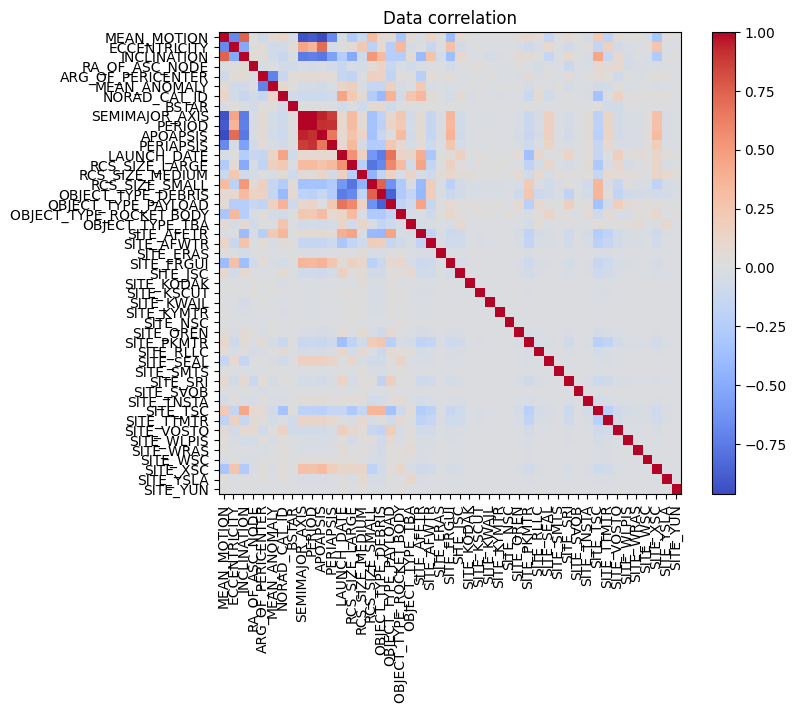

In [ ]:
# Повторная корреляционная матрица после добавления закодированных признаков
corr = df[num_cols].corr(numeric_only=True)
plt.figure(figsize=(8, 6))
plt.imshow(corr, cmap='coolwarm', interpolation='nearest')
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.colorbar()
plt.title("Data correlation")
plt.show()


In [ ]:
# Преобразование булевых столбцов (True/False) в целочисленные (1/0)
# для совместимости с числовыми операциями и моделями ML
bool_cols = df.select_dtypes(include=['bool']).columns
df[bool_cols] = df[bool_cols].astype(int)

print(f"Converted Boolean columns: {len(bool_cols)}")
df.head()


Converted Boolean columns: 34


,EPOCH,MEAN_MOTION,ECCENTRICITY,INCLINATION,RA_OF_ASC_NODE,ARG_OF_PERICENTER,MEAN_ANOMALY,NORAD_CAT_ID,BSTAR,SEMIMAJOR_AXIS,PERIOD,APOAPSIS,PERIAPSIS,LAUNCH_DATE,RCS_SIZE_LARGE,RCS_SIZE_MEDIUM,RCS_SIZE_SMALL,OBJECT_TYPE_DEBRIS,OBJECT_TYPE_PAYLOAD,OBJECT_TYPE_ROCKET BODY,OBJECT_TYPE_TBA,SITE_AFETR,SITE_AFWTR,SITE_ERAS,SITE_FRGUI,SITE_JSC,SITE_KODAK,SITE_KSCUT,SITE_KWAJL,SITE_KYMTR,SITE_NSC,SITE_OREN,SITE_PKMTR,SITE_RLLC,SITE_SEAL,SITE_SMTS,SITE_SRI,SITE_SVOB,SITE_TNSTA,SITE_TSC,SITE_TTMTR,SITE_VOSTO,SITE_WLPIS,SITE_WRAS,SITE_WSC,SITE_XSC,SITE_YSLA,SITE_YUN
0,2021-10-31 22:46:50.340864,2.921700,0.652893,7.7156,90.2410,243.1216,38.7796,26741,0.024341,20668.618,492.864,27784.871,796.095,1992.0,0,1,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,2021-10-31 16:32:17.360448,13.754973,0.003072,82.9193,299.1120,158.9093,201.3337,26743,0.000066,7358.038,104.689,1002.507,957.299,1979.0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,2021-11-01 05:22:43.421952,1.038224,0.023739,12.1717,16.5368,250.1248,146.2900,26745,0.000000,41197.852,1386.984,35797.696,33841.738,2001.0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0
3,2021-10-31 11:11:24.198720,14.775907,0.006062,98.4781,8.7205,37.3771,323.1632,26754,0.000316,7015.076,97.456,679.465,594.417,1999.0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0
4,2021-10-31 17:46:46.681248,14.724482,0.006226,98.4232,122.0724,345.1605,27.6061,26755,0.000408,7031.400,97.796,697.039,609.491,1999.0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0


In [ ]:
# Отбор признаков по корреляции с целевой переменной PERIOD (орбитальный период).
# Оставляем только признаки с |корреляция| > 0.3 — убираем слабосвязанные
target_corr = df.corr(numeric_only=True)['PERIOD'].abs().sort_values(ascending=False)

threshold = 0.3
useful_features = target_corr[target_corr > threshold].index.tolist()

print("We leave signs:", useful_features)

df_reduced = df[useful_features]
df_reduced.head()


We leave signs: ['PERIOD', 'SEMIMAJOR_AXIS', 'APOAPSIS', 'PERIAPSIS', 'MEAN_MOTION', 'INCLINATION', 'ECCENTRICITY', 'SITE_FRGUI', 'RCS_SIZE_SMALL', 'RCS_SIZE_LARGE']


,PERIOD,SEMIMAJOR_AXIS,APOAPSIS,PERIAPSIS,MEAN_MOTION,INCLINATION,ECCENTRICITY,SITE_FRGUI,RCS_SIZE_SMALL,RCS_SIZE_LARGE
0,492.864,20668.618,27784.871,796.095,2.921700,7.7156,0.652893,1,0,0
1,104.689,7358.038,1002.507,957.299,13.754973,82.9193,0.003072,0,1,0
2,1386.984,41197.852,35797.696,33841.738,1.038224,12.1717,0.023739,0,0,1
3,97.456,7015.076,679.465,594.417,14.775907,98.4781,0.006062,0,1,0
4,97.796,7031.400,697.039,609.491,14.724482,98.4232,0.006226,0,1,0


In [ ]:
# Обновляем список числовых столбцов для отобранного датафрейма
num_cols2 = [c for c in df_reduced.columns if pd.api.types.is_numeric_dtype(df[c])]

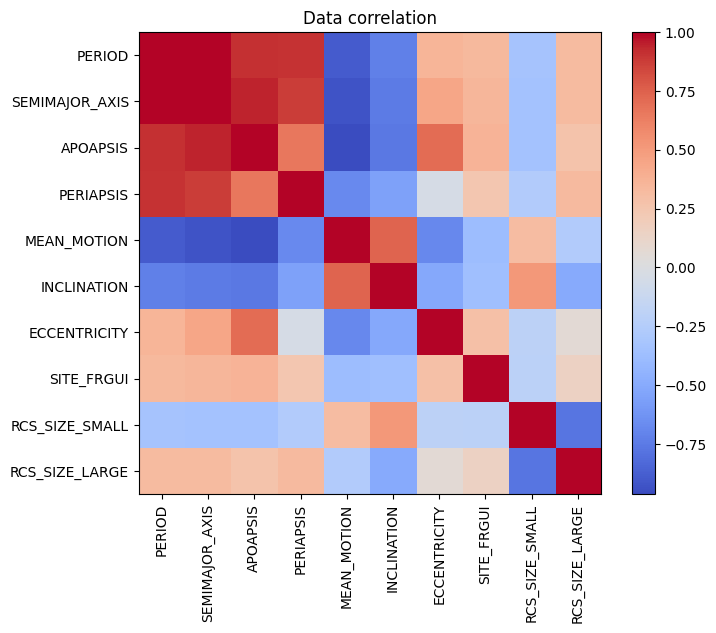

In [ ]:
# Корреляционная матрица финального набора признаков
corr = df[num_cols2].corr(numeric_only=True)
plt.figure(figsize=(8, 6))
plt.imshow(corr, cmap='coolwarm', interpolation='nearest')
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.colorbar()
plt.title("Data correlation")
plt.show()


In [ ]:
# Сохранение итогового очищенного и подготовленного датасета в CSV-файл
df.to_csv("orbits.csv", index=False)
